# V4 Results Analysis

GSM-Infinity RL v4 experiments with skewed pretrained model (op=2-10)

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
os.chdir('/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/')
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [68]:
# Config
RESULTS_DIR = Path("../results/gsm_infinity_rl_v4")
PASS_K_VALUES = [1, 2, 4, 8, 16, 32, 64, 128]

# Difficulty groups (by num_ops)
DIFFICULTY_GROUPS = {
    "ID (op=2-10)": list(range(2, 11)),
    "OOD-mid (op=11-14)": list(range(11, 15)),
    "OOD-hard (op=15-20)": list(range(15, 21)),
}

# Display names for all known runs
DISPLAY_NAMES = {
    "base_model_eval_pass128": "Base (skewed)",
    # GRPO variants
    "grpo_id_v4": "GRPO (ID)",
    "grpo_edge_v4": "GRPO (Edge)",
    "grpo_hard_v4": "GRPO (Hard)",
    "grpo_uniform_v4": "GRPO (Uniform)",
    "grpo_mixed_v4": "GRPO (Mixed)",
    # GRPO dpg runs
    "grpo_dpg_eta1_edge_v4": "GRPO (DPG-η1)",
    "grpo_dpg_eta2_edge_v4": "GRPO (DPG-η2)",
    "grpo_dpg_eta05_edge_v4": "GRPO (DPG-η0.5)",
    "grpo_dpg_eta8_edge_v4": "GRPO (DPG-η8)",
    "grpo_dpg_eta32_edge_v4": "GRPO (DPG-η32)",
    "grpo_dpg_eta128_edge_v4": "GRPO (DPG-η32)",
    # MGPO uniform runs
    "mgpo_uniform_v4_lambda2": "MGPO-λ2 (Uniform)",
    "mgpo_uniform_v4_lambda4": "MGPO-λ4 (Uniform)",
    "mgpo_uniform_v4_lambda6": "MGPO-λ6 (Uniform)",
    # DR-GSPO Edge runs
    "dr_gspo_edge_v4": "DR-GSPO (Edge)",
    "dr_gspo_eta005_edge_v4": "DR-GSPO-η0.05 (Edge)",
    "dr_gspo_eta01_edge_v4": "DR-GSPO-η0.1 (Edge)",
    "dr_gspo_eta05_edge_v4": "DR-GSPO-η0.5 (Edge)",
    "dr_gspo_eta075_edge_v4": "DR-GSPO-η0.75 (Edge)",
    # DR-GSPO Hard runs
    "dr_gspo_hard_v4": "DR-GSPO (Hard)",
    "dr_gspo_eta005_hard_v4": "DR-GSPO-η0.05 (Hard)",
    "dr_gspo_eta1_hard_v4": "DR-GSPO-η1 (Hard)",
    "dr_gspo_eta8_hard_v4": "DR-GSPO-η8 (Hard)",
}

# ============ RUN SETS (edit these to switch what you visualize) ============

# DR-GSPO Edge eta sweep (only runs with eval)
RUN_SET_DR_GSPO_EDGE = [
    "dr_gspo_edge_v4",
    "dr_gspo_eta005_edge_v4",
    "dr_gspo_eta01_edge_v4",
    "dr_gspo_eta05_edge_v4",
    "dr_gspo_eta8_edge_v4",
    "dr_gspo_eta075_edge_v4",
]
# GRPO dpg runs
RUN_SET_GRPO_DPG = [
    "grpo_edge_v4",
    "grpo_dpg_eta1_edge_v4",
    "grpo_dpg_eta05_edge_v4",
    "grpo_dpg_eta8_edge_v4",
    "grpo_dpg_eta32_edge_v4",
    "grpo_dpg_eta128_edge_v4",
    "grpo_dpg_eta2_edge_v4",
    "dr_gspo_eta05_edge_v4",
]

# DR-GSPO Hard eta sweep
RUN_SET_DR_GSPO_HARD = [
    "dr_gspo_hard_v4",
    "dr_gspo_eta005_hard_v4",
    "dr_gspo_eta1_hard_v4",
    "dr_gspo_eta8_hard_v4",
]

# Uniform training: GRPO + MGPO lambda sweep
RUN_SET_UNIFORM = [
    "grpo_uniform_v4",
    "mgpo_uniform_v4_lambda2",
    "mgpo_uniform_v4_lambda4",
    "mgpo_uniform_v4_lambda6",
]

RUN_SET_BASE = [
    "grpo_uniform_v4",
    "grpo_id_v4",
    "grpo_edge_v4",
    "grpo_hard_v4",
    "dr_gspo_edge_v4",
]

# ============ ACTIVE RUN SET (change this line to switch) ============
ACTIVE_RUN_SET = RUN_SET_GRPO_DPG  # Options: RUN_SET_DR_GSPO_EDGE, RUN_SET_DR_GSPO_HARD, RUN_SET_UNIFORM

In [69]:
def find_eval_metrics(run_dir):
    """Find eval_pass128/metrics.jsonl at any checkpoint step, preferring the latest."""
    candidates = sorted(
        run_dir.glob("global_step_*/eval_pass128/metrics.jsonl"),
        key=lambda p: int(p.parent.parent.name.split("_")[-1]),
        reverse=True,
    )
    return candidates[0] if candidates else None


def load_metrics(run_name):
    """Load metrics for a run. Returns (metrics_dict, source_description) or (None, reason).
    
    For training runs (those with latest_checkpointed_iteration.txt):
      - Only loads from eval_pass128 at a checkpoint. Never falls back to
        root metrics.jsonl, which contains val_before_train (= base model).
    For standalone eval runs (no latest_checkpointed_iteration.txt):
      - Loads from root metrics.jsonl (e.g. base_model_eval_pass128).
    """
    run_dir = RESULTS_DIR / run_name
    iter_file = run_dir / "latest_checkpointed_iteration.txt"
    
    if iter_file.exists():
        # This is a training run -- only trust eval_pass128 results
        step = iter_file.read_text().strip()
        eval_path = find_eval_metrics(run_dir)
        if eval_path is not None:
            eval_step = eval_path.parent.parent.name
            with open(eval_path) as f:
                metrics = json.loads(f.readline())["metrics"]
            return metrics, f"eval_pass128 @ {eval_step} (latest={step})"
        return None, f"NO EVAL (latest training step={step})"
    
    # Standalone eval (no training checkpoints) -- root metrics.jsonl is fine
    metrics_file = run_dir / "metrics.jsonl"
    if metrics_file.exists():
        with open(metrics_file) as f:
            return json.loads(f.readline())["metrics"], "standalone eval"
    
    return None, "directory not found"


def extract_pass_k(metrics, difficulty_ops, k):
    """Extract pass@k for a given difficulty group."""
    key_pattern = f"val-aux/difficulty-5B/{{}}/reward/pass@{k}"
    vals = []
    for op in difficulty_ops:
        key = key_pattern.format(op)
        if key in metrics:
            vals.append(metrics[key])
    return np.mean(vals) if vals else 0.0


def get_run_data(run_name):
    """Get all pass@k values for a run across difficulty groups."""
    metrics, source = load_metrics(run_name)
    if metrics is None:
        return None, source
    
    data = {}
    for group_name, ops in DIFFICULTY_GROUPS.items():
        data[group_name] = {k: extract_pass_k(metrics, ops, k) for k in PASS_K_VALUES}
    return data, source

In [70]:
# List available v4 runs
print("Available v4 runs:")
print(f"{'Run':<40} {'Step':>5}  {'Status'}")
print("-" * 80)
for d in sorted(RESULTS_DIR.iterdir()):
    if d.is_dir():
        iter_file = d / "latest_checkpointed_iteration.txt"
        metrics_file = d / "metrics.jsonl"
        if iter_file.exists():
            step = iter_file.read_text().strip()
            eval_path = find_eval_metrics(d)
            if eval_path is not None:
                eval_step = eval_path.parent.parent.name
                if eval_step == f"global_step_{step}":
                    status = f"EVAL_COMPLETE @ {eval_step}"
                else:
                    status = f"EVAL @ {eval_step} (latest={step}, MISMATCH)"
            else:
                status = "EVAL_MISSING -- will be SKIPPED in plots"
            print(f"  {d.name:<38} {step:>5}  {status}")
        elif metrics_file.exists():
            print(f"  {d.name:<38}     -  standalone eval (base model)")

Available v4 runs:
  base_model_eval_pass128: COMPLETE (base model eval)
  dr_gspo_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta005_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta005_hard_v4: step=386, EVAL_COMPLETE
  dr_gspo_eta01_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta05_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta05_edge_v4 copy: step=388, EVAL_COMPLETE
  dr_gspo_eta075_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta1_edge_v4: step=388, EVAL_MISSING
  dr_gspo_eta1_hard_v4: step=386, EVAL_COMPLETE
  dr_gspo_eta2_edge_v4: step=330, EVAL_MISSING
  dr_gspo_eta8_hard_v4: step=386, EVAL_COMPLETE
  dr_gspo_hard_v4: step=386, EVAL_COMPLETE
  grpo_dpg_eta05_edge_v4: step=388, EVAL_COMPLETE
  grpo_dpg_eta128_edge_v4: step=388, EVAL_MISSING
  grpo_dpg_eta1_edge_v4: step=388, EVAL_COMPLETE
  grpo_dpg_eta2_edge_v4: step=390, EVAL_MISSING
  grpo_dpg_eta32_edge_v4: step=310, EVAL_MISSING
  grpo_dpg_eta4_edge_v4: step=70, EVAL_MISSING
  grpo_dpg_eta8_edge_v4: step=388, EVAL_COMPLETE
  grpo_

In [71]:
# Load data for active run set
V4_RUNS = ACTIVE_RUN_SET

v4_data = {}
for run in V4_RUNS:
    data, source = get_run_data(run)
    if data is not None:
        v4_data[run] = data
        print(f"  OK  {run:<40} ({source})")
    else:
        print(f"  SKIP {run:<40} ({source})")

print(f"\nTotal runs loaded: {len(v4_data)}")

Loaded: grpo_edge_v4
Loaded: grpo_dpg_eta1_edge_v4
Loaded: grpo_dpg_eta05_edge_v4
Loaded: grpo_dpg_eta8_edge_v4
Loaded: grpo_dpg_eta32_edge_v4
Loaded: grpo_dpg_eta128_edge_v4
Loaded: grpo_dpg_eta2_edge_v4
Loaded: dr_gspo_eta05_edge_v4

Total runs loaded: 8


In [72]:
# Summary table
def summary_table(runs, data):
    rows = []
    for run in runs:
        if run not in data:
            continue
        row = {"Run": DISPLAY_NAMES.get(run, run)}
        for group in DIFFICULTY_GROUPS.keys():
            row[f"{group} pass@1"] = f"{data[run][group][1]*100:.1f}"
            row[f"{group} pass@128"] = f"{data[run][group][128]*100:.1f}"
        rows.append(row)
    return pd.DataFrame(rows)

summary_table(V4_RUNS, v4_data)

,Run,ID (op=2-10) pass@1,ID (op=2-10) pass@128,OOD-mid (op=11-14) pass@1,OOD-mid (op=11-14) pass@128,OOD-hard (op=15-20) pass@1,OOD-hard (op=15-20) pass@128
0,GRPO (Edge),80.5,96.5,49.0,85.7,4.8,16.6
1,GRPO (DPG-η1),0.1,0.8,0.0,0.0,0.0,0.0
2,GRPO (DPG-η0.5),0.0,0.0,0.0,0.0,0.0,0.0
3,GRPO (DPG-η8),0.0,2.3,0.0,0.0,0.0,0.0
4,GRPO (DPG-η32),97.2,99.8,49.5,77.5,16.4,44.6
5,GRPO (DPG-η32),97.2,99.8,49.5,77.5,16.4,44.6
6,GRPO (DPG-η2),0.0,0.0,0.0,0.0,0.0,0.0
7,DR-GSPO-η0.5 (Edge),79.9,96.6,48.9,85.1,5.8,20.2


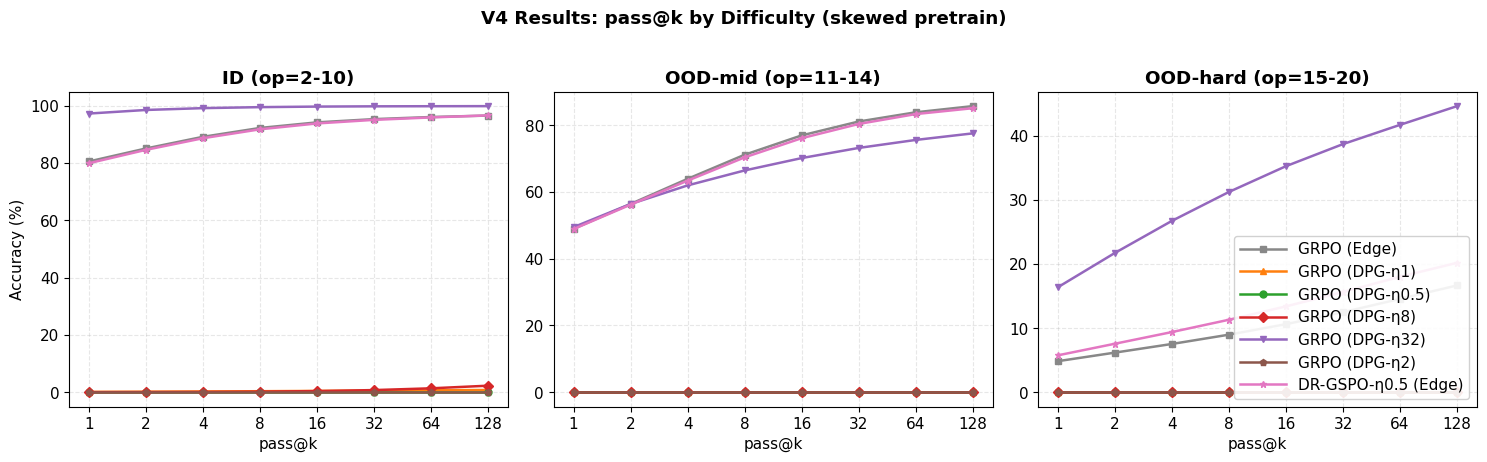

In [73]:
# Plot: Methods comparison (1x3 grid for all difficulty groups)
# Auto-generate runs_to_plot from loaded data
runs_to_plot = {DISPLAY_NAMES.get(r, r): r for r in V4_RUNS if r in v4_data}

# Color palette for up to 10 runs
_COLORS = ["#888888", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
_MARKERS = ["s", "^", "o", "D", "v", "p", "*", "h", "X", "P"]

colors = {label: _COLORS[i % len(_COLORS)] for i, label in enumerate(runs_to_plot.keys())}
markers = {label: _MARKERS[i % len(_MARKERS)] for i, label in enumerate(runs_to_plot.keys())}
linestyles = {label: ("--" if "Base" in label else "-") for label in runs_to_plot.keys()}

groups = ["ID (op=2-10)", "OOD-mid (op=11-14)", "OOD-hard (op=15-20)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax_idx, group in enumerate(groups):
    ax = axes[ax_idx]
    for label, run_name in runs_to_plot.items():
        if run_name not in v4_data:
            continue
        y = [v4_data[run_name][group][k] * 100 for k in PASS_K_VALUES]
        ax.plot(
            range(len(PASS_K_VALUES)), y,
            marker=markers[label], markersize=5, linewidth=1.8,
            color=colors[label], linestyle=linestyles[label],
            label=label,
        )
    ax.set_title(group, fontweight="bold")
    ax.set_xticks(range(len(PASS_K_VALUES)))
    ax.set_xticklabels([str(k) for k in PASS_K_VALUES])
    ax.set_xlabel("pass@k")
    ax.grid(True, alpha=0.3, linestyle="--")

axes[0].set_ylabel("Accuracy (%)")
axes[2].legend(loc="lower right", framealpha=0.9, handlelength=3.0)
fig.suptitle("V4 Results: pass@k by Difficulty (skewed pretrain)", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("figures/v4_performance.png", dpi=200, bbox_inches="tight")
plt.show()